# OTF Scan Plan

Plan a simple raster scan in galactic coordinates.
Check alt/az limits at the planned observation time and visualize coverage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
import astropy.coordinates as ac
from astropy.time import Time, TimeDelta

%matplotlib inline
plt.rcParams.update({"figure.dpi": 140, "figure.facecolor": "white"})

# Leuschner Observatory
LEO_LAT, LEO_LON, LEO_ALT = 37.9183, -122.1067, 304.0
location = ac.EarthLocation(lat=LEO_LAT * u.deg, lon=LEO_LON * u.deg,
                            height=LEO_ALT * u.m)

## 1. Scan configuration

In [2]:
# --- Scan grid ---
# Anti-center mid-latitude: accessible from 10 PM PDT, ~4.5h window
# HI brightness ~10–30 K at |b|=30 → need more integration than plane
L_CENTER   = 180.0     # galactic longitude center (anti-center)
B_CENTER   =  30.0     # galactic latitude center
L_EXTENT   =  7        # cells per row
B_EXTENT   =  4        # number of b-rows (b = 28.5 to 31.5)
STEP_DEG   =  1.0      # grid spacing

# --- Observation timing ---
T_START = Time("2026-04-17 05:00:00", scale="utc")  # 10:00 PM PDT Apr 16

# --- Hardware ---
HPBW_DEG       = 3.4
DUMPS_PER_BAND = 16     # 16 dumps/band for mid-latitude SNR ~12
DUMPS_PER_CELL = DUMPS_PER_BAND * 2
NBLOCKS        = 1025
NSAMPLES       = 32768
SAMPLE_RATE    = 2.56e6
MIN_ALT_DEG    = 17.0
AZ_MIN, AZ_MAX = 7.0, 348.0

DUMP_CADENCE_S = NBLOCKS * NSAMPLES / SAMPLE_RATE + 1.5
CELL_DWELL_S   = DUMPS_PER_CELL * DUMP_CADENCE_S
SLEW_TIME_S    = 5.0
CELL_TIME_S    = CELL_DWELL_S + SLEW_TIME_S

n_cells = L_EXTENT * B_EXTENT
pass_time_h = n_cells * CELL_TIME_S / 3600

print(f'Grid: {L_EXTENT} x {B_EXTENT} = {n_cells} cells')
print(f'Center: l={L_CENTER}, b={B_CENTER}')
print(f'l range: [{L_CENTER - (L_EXTENT-1)/2:.0f}, {L_CENTER + (L_EXTENT-1)/2:.0f}]')
print(f'b range: [{B_CENTER - (B_EXTENT-1)/2:.0f}, {B_CENTER + (B_EXTENT-1)/2:.0f}]')
print(f'Dumps per band: {DUMPS_PER_BAND} (4x galactic plane for mid-lat SNR)')
print(f'Cell time: {CELL_TIME_S:.0f} s = {CELL_TIME_S/60:.1f} min ({DUMPS_PER_CELL} dumps)')
print(f'Estimated pass time: {pass_time_h:.1f} h')
print(f'Start: {T_START.iso} UTC (10:00 PM PDT)')
print()
print(f'Window: ~4.5h (alt 61° → 17° by ~2:30 AM PDT)')

Grid: 7 x 4 = 28 cells
Center: l=180.0, b=30.0
l range: [177, 183]
b range: [28, 32]
Dumps per band: 16 (4x galactic plane for mid-lat SNR)
Cell time: 473 s = 7.9 min (32 dumps)
Estimated pass time: 3.7 h
Start: 2026-04-17 05:00:00.000 UTC (10:00 PM PDT)

Window: ~4.5h (alt 61° → 17° by ~2:30 AM PDT)


## 2. Build grid and check visibility

In [3]:
# Build simple raster grid (no parallelogram slant)
b_vals = np.arange(B_CENTER - (B_EXTENT-1)/2, B_CENTER + (B_EXTENT-1)/2 + 0.1, STEP_DEG)
l_vals = np.arange(L_CENTER - (L_EXTENT-1)/2, L_CENTER + (L_EXTENT-1)/2 + 0.1, STEP_DEG)

# Boustrophedon ordering, decreasing l first (follows sky rotation)
cell_list = []
for row_idx, b in enumerate(b_vals):
    row = [(int(l), int(b)) for l in l_vals]
    if row_idx % 2 == 0:
        row = list(reversed(row))  # decreasing l on even rows
    cell_list.extend(row)

print(f'{len(cell_list)} cells in scan order')
print(f'b range: [{int(b_vals[0])}, {int(b_vals[-1])}]')
print(f'l range: [{int(l_vals[0])}, {int(l_vals[-1])}]')

# Simulate timing and check alt/az
sim = []
t_current = T_START
n_bad = 0
for idx, (cell_l, cell_b) in enumerate(cell_list):
    t_mid = t_current + TimeDelta(CELL_DWELL_S / 2, format='sec')
    gc = ac.SkyCoord(l=cell_l * u.deg, b=cell_b * u.deg, frame='galactic')
    icrs = gc.transform_to(ac.ICRS())
    altaz = gc.transform_to(ac.AltAz(obstime=t_mid, location=location))
    alt, az = altaz.alt.deg, altaz.az.deg
    bad = alt < MIN_ALT_DEG or az < AZ_MIN or az > AZ_MAX
    if bad:
        n_bad += 1
    sim.append({
        'idx': idx, 'l': cell_l, 'b': cell_b,
        'alt': alt, 'az': az,
        'ra': icrs.ra.deg, 'dec': icrs.dec.deg,
        'time': t_mid, 'bad': bad,
    })
    t_current += TimeDelta(CELL_TIME_S, format='sec')

t_end = t_current
alts = [s['alt'] for s in sim]
azs = [s['az'] for s in sim]

print(f'\nDuration: {(t_end - T_START).sec/3600:.1f} h')
print(f'Alt range: {min(alts):.1f} – {max(alts):.1f} deg')
print(f'Az range:  {min(azs):.1f} – {max(azs):.1f} deg')
if n_bad:
    print(f'WARNING: {n_bad} cells outside telescope limits!')
else:
    print('All cells within telescope limits.')

28 cells in scan order
b range: [28, 31]
l range: [177, 183]

Duration: 3.7 h
Alt range: 22.4 – 58.5 deg
Az range:  281.4 – 302.2 deg
All cells within telescope limits.


## 3. Visualize scan pattern

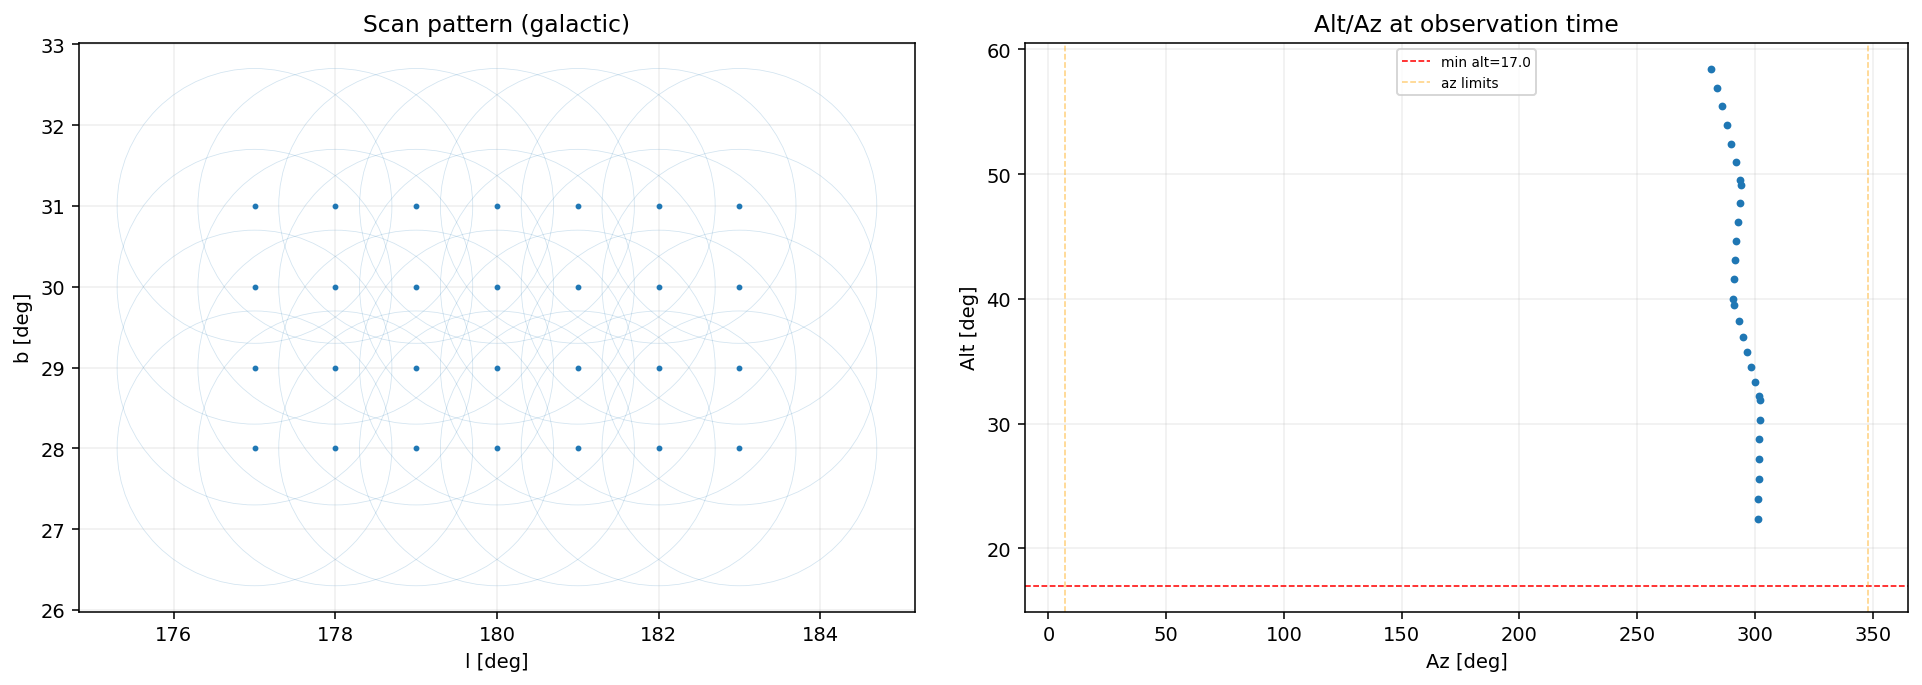

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Galactic coordinates ---
ax = axes[0]
for s in sim:
    color = 'red' if s['bad'] else 'C0'
    beam = Circle((s['l'], s['b']), HPBW_DEG/2,
                  fill=False, edgecolor=color, alpha=0.2, lw=0.4)
    ax.add_patch(beam)
    ax.plot(s['l'], s['b'], 'o', color=color, ms=2)
ax.set_xlabel('l [deg]')
ax.set_ylabel('b [deg]')
ax.set_title('Scan pattern (galactic)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

# --- Alt/Az ---
ax = axes[1]
for s in sim:
    color = 'red' if s['bad'] else 'C0'
    ax.plot(s['az'], s['alt'], 'o', color=color, ms=3)
ax.axhline(MIN_ALT_DEG, color='red', ls='--', lw=0.8, label=f'min alt={MIN_ALT_DEG}')
ax.axvline(AZ_MIN, color='orange', ls='--', lw=0.8, alpha=0.5)
ax.axvline(AZ_MAX, color='orange', ls='--', lw=0.8, alpha=0.5, label=f'az limits')
ax.set_xlabel('Az [deg]')
ax.set_ylabel('Alt [deg]')
ax.set_title('Alt/Az at observation time')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

fig.tight_layout()
plt.show()

/tmp/ipykernel_856887/2539518970.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


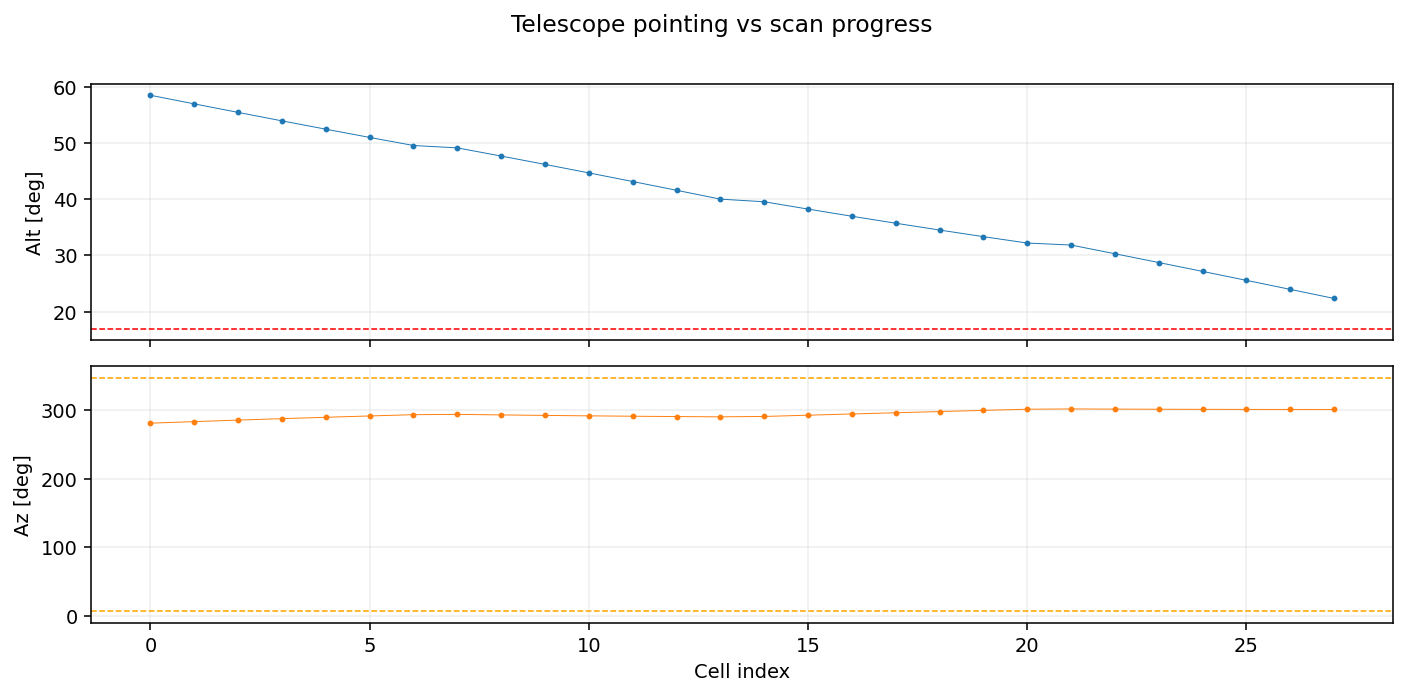

In [5]:
# Timeline: alt and az vs cell index
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                                gridspec_kw={'hspace': 0.1})

idxs = [s['idx'] for s in sim]
ax1.plot(idxs, alts, 'o-', ms=2, lw=0.5, color='C0')
ax1.axhline(MIN_ALT_DEG, color='red', ls='--', lw=0.8)
ax1.set_ylabel('Alt [deg]')
ax1.grid(True, alpha=0.2)

ax2.plot(idxs, azs, 'o-', ms=2, lw=0.5, color='C1')
ax2.axhline(AZ_MIN, color='orange', ls='--', lw=0.8)
ax2.axhline(AZ_MAX, color='orange', ls='--', lw=0.8)
ax2.set_ylabel('Az [deg]')
ax2.set_xlabel('Cell index')
ax2.grid(True, alpha=0.2)

fig.suptitle('Telescope pointing vs scan progress')
fig.tight_layout()
plt.show()